(drawing-circles-section)=
# Drawing circles

Now that we have the ability to rasterise straight lines the next fundamental problem is the rasterisation of circles. This can be done by deriving a Bresenham-type algorithm that uses the [Cartesian equation of a circle](https://en.wikipedia.org/wiki/Circle#Equations) to determine which of two candidate pixels are plotted.

The circle line drawing algorithms can use the concept of **circle symmetry** to reduce the number of computations required to rasterise a circle. Consider {numref}`circle-symmetry-figure` where a circle is centred at the origin. If the coordinate of a point on the circle in the shaded octant where $x > y$ is known to be $(x,y)$ then the corresponding points on the circle in the other seven octants can be found via circle symmetry through combinations of $(\pm x,\pm y)$ and $(\pm y,\pm x)$.

:::{glue:figure} circle-symmetry-plot
:name: circle-symmetry-figure
:figwidth: 400px

Circle symmetry can be used to calculate points on a circle.
:::

For circles not centred at the original, which will be the case in the vast majority of applications, we calculate the co-ordinates of a point on the circle in the first octant $(x, y)$ and then add the co-ordinates of the circle centre $(c_x,c_y)$ giving the following eight pixel co-ordinates

\begin{align*}
    (c_x + x, c_y + y), & 
    &(c_x + x, c_y - y), \\
    (c_x - x, c_y + y), &
    &(c_x - x, c_y - y), \\
    (c_x + y, c_y + x), &
    &(c_x + y, c_y - x), \\
    (c_x - y, c_y + x), &
    &(c_x - y, c_y - x).
\end{align*}

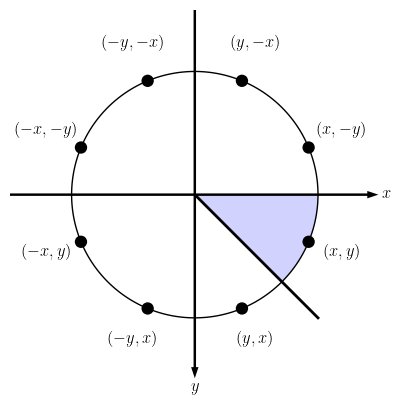

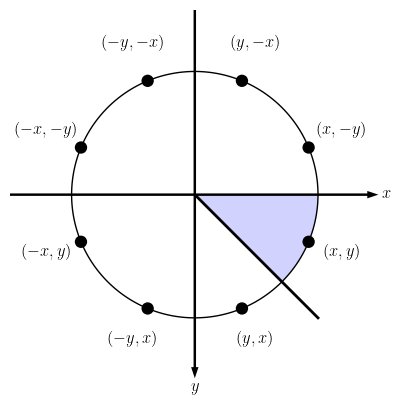

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc       
from myst_nb import glue
plt.rcParams['text.usetex'] = True

blue = np.array([210, 210, 255]) / 255
green = [230, 255, 230]
white = [255, 255, 255]

fig, ax = plt.subplots()

phi = np.arange(-np.pi / 4, 0, 0.001)
x, y = np.cos(phi), np.sin(phi)
x = np.append(x, 0)
y = np.append(y, 0)
plt.fill(x, y, fc=blue, ec="none")

theta = np.linspace(0, 2 * np.pi, 200)
x, y = np.cos(theta), np.sin(theta)
plt.plot(x, y, "k", lw=1)

xl = ["x", "y", "-y", "-x", "-x", "-y", "y", "x"]
yl = ["-y", "-x", "-x", "-y", "y", "x", "x", "y"]
theta = np.arange(np.pi / 8, 2 * np.pi, np.pi / 4)

for i in range(8):
    x, y = np.cos(theta[i]), np.sin(theta[i])
    ax.add_patch(plt.Circle((x, y), 0.05, fc="k"))
    x, y = 1.3 * x, 1.3 * y
    plt.text(x, y, s=rf"$({xl[i]}, {yl[i]})$", ha="center", fontsize=12)

plt.plot([0, 1], [0, -1], "k", lw=2)
plt.arrow(x=-1.5, y=0, dx=2.9, dy=0, width=0.02, fc='k', ec='none') 
plt.arrow(x=0, y=1.5, dx=0, dy=-2.9, width=0.02, fc='k', ec='none') 
plt.text(x=1.52, y=-0.025, s="$x$",fontsize=12)
plt.text(x=0, y=-1.6, s="$y$",fontsize=12,ha="center")

ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_aspect("equal")
ax.axis("off")

glue("circle-symmetry-plot", fig, display=False)

## The midpoint algorithm

The **midpoint algorithm** {cite}`pitteway:1967` is a form of Bresenham's algorithm that is used to draw circles. Consider the <a href="https://en.wikipedia.org/wiki/Circle#Equations" target="_blank">Cartesian equation of a circle</a> centred at $(0, 0)$ with radius $r$

$$x^2 + y^2 = r^2,$$

which an be rearranged to give

$$0 = x^2 + y^2 - r^2,$$

and defining the function $f(x,y)$ as

$$f(x,y) = x^2 + y^2 - r^2,$$

then if $f(x,y)=0$ we know that the point $(x,y)$ is on the circle. 

:::{glue:figure} midpoint-algorithm-plot
:figwidth: 300px

Determining the pixels on a circle using the midpoint algorithm.
:::

To derive an algorithm to rasterise a circle we assume that the circle is centred at $(0, 0)$ and we start at the pixel at the 3 o'clock position with pixel co-ordinates $(r,0)$. We then move clockwise around the circle calculating the pixels that lie closest to the idealised circle until $x=y$ which is the end of the first octant. For each pixel co-ordinates we calculate, the pixel co-ordinates of the corresponding pixels in the 7 other octants are calculated using circle symmetry. 

Once the first pixel $(r,0)$ is plotted we move down by one pixel so that $y=1$ and we have a choice between the two pixels at $(r,1)$ and $(r-1,1)$ to plot next. Similar to Bresenham's line drawing algorithm, we define a value $D$ as the difference between the value of $f(x,y)$ between the first pixel $(r,0)$ and the midpoint between the two pixels $(r,1)$ and $(r-1,1)$.

:::{math}
:label: midpoint-equation-1

\begin{align}
    \notag D &= f \left( r-\tfrac{1}{2}, 1 \right) - f(r, 0) \\
    \notag &= \left( r-\tfrac{1}{2} \right)^2 + 1^2 - r^2 - r^2 - 0^2 + r^2 \\
    \notag &= r^2 - r + \tfrac{1}{4} + 1 - r^2 \\
    &= \tfrac{5}{4} - r.
\end{align}
:::

If $D \leq 0$ then the midpoint is inside the circle so we plot the pixel at $(x,y+1)$ and the change in the value of $D$ is

:::{math}
:label: midpoint-equation-2

\begin{align}
    \Delta D_{inside} &= f\left( x-\tfrac{1}{2},y+2 \right) - f\left(x-\tfrac{1}{2},y+1\right) \\
    &= \left(x-\tfrac{1}{2}\right)^2 + (y+2)^2 - r^2 - \left(x-\tfrac{1}{2}\right)^2 - (y+1)^2 + r^2 \\
    &= y^2 + 4y + 4 - y^2 - y - 1 \\
    &= 2y + 3.
\end{align}
:::

Else if $D > 0$ then the midepoint is outside ofhte circle so we plot the pixel at $(x-1,y+1)$ and the change in the value of $D$ is

:::{math}
:label: midpoint-equation-3

\begin{align}
    \notag \Delta D_{outside} &= f\left(x-\tfrac{3}{2},y+2\right) - f\left(x-\tfrac{1}{2}, y+1\right) \\
    \notag &= \left(x-\tfrac{3}{2}\right)^2 + (y+2)^2 - r^2 - \left(x-\tfrac{1}{2}\right)^2 - (y+1)^2 + r^2 \\
    \notag &= x^2 - 3x + \tfrac{9}{4} + y^2 + 4y + 4 - x^2 + x - \tfrac{1}{4} - y^2 - 2y - 1 \\
    &= 2y - 2x + 5.
\end{align}
:::

Equation {eq}`midpoint-equation-1` contains a floating point number in $\frac{5}{4}$, similar to Bresenham's algorithm we can multiply equations {eq}`midpoint-equation-1` to {eq}`midpoint-equation-3` by 4 so that we have integer only expressions for $D$, $\Delta D_{inside}$ and $\Delta_{outside}$

:::{math}
:label: midpoint-equations

\begin{align}
    D &= 5 - 4r, \\
    \Delta D_{inside} &= 8y + 12, \\
    \Delta D_{outside} &= 8y - 8x + 20.
\end{align}
:::

Note that the values of $\Delta D_{inside}$ and $\Delta D_{outside}$ depend on the current values of $x$ and $y$ so cannot be pre-calculated.

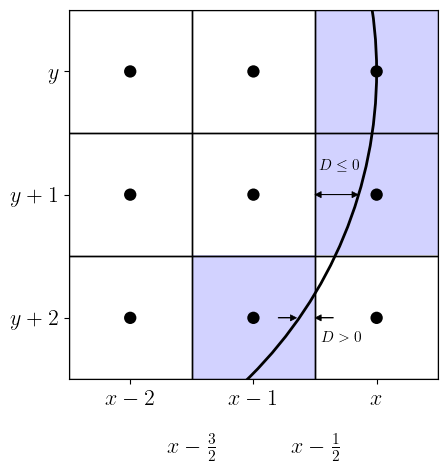

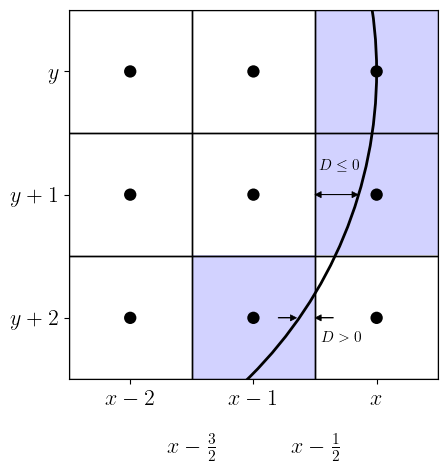

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from myst_nb import glue
plt.rcParams['text.usetex'] = True

blue = [210, 210, 255]
                
Nx, Ny = 3, 3
img = 255 * np.ones((Ny, Nx, 3)).astype(int)
img[0:2,-1,:] = blue
img[2,1,:] = blue

fig, ax = plt.subplots()

imgplot = plt.imshow(img)
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))
        ax.add_patch(plt.Circle((i, j), 0.05, fc="k"))
   
ax.add_patch(plt.Circle((-1.5, 0), lw=2, radius=3.5, fill=False))
plt.yticks([0, 1, 2], ["$y$", "$y + 1$", "$y + 2$"], fontsize=16)
plt.xticks([0, 1, 2], ["$x - 2$", "$x - 1$", "$x$"], fontsize=16)
plt.text(0.5, 3.1, s=r"$x-\frac{3}{2}$", ha="center", fontsize=16)
plt.text(1.5, 3.1, s=r"$x-\frac{1}{2}$", ha="center", fontsize=16)
plt.arrow(1.5, 1, 0.35, 0, head_width=0.05, head_length=0.05, linewidth=0.5, color='k', length_includes_head=True)
plt.arrow(1.85, 1, -0.35, 0, head_width=0.05, head_length=0.05, linewidth=0.5, color='k', length_includes_head=True)
plt.text(1.7, 0.8, s=r"$D \leq 0$", ha="center", fontsize=11)
plt.arrow(1.2, 2, 0.15, 0, head_width=0.05, head_length=0.05, linewidth=0.5, color='k', length_includes_head=True)
plt.arrow(1.65, 2, -0.15, 0, head_width=0.05, head_length=0.05, linewidth=0.5, color='k', length_includes_head=True)
plt.text(1.55, 2.2, s=r"$D > 0$", ha="left", fontsize=11)
ax.set_xlim([-0.5, 2.5])
ax.set_ylim([2.5, -0.5])

glue("midpoint-algorithm-plot", fig, display=False)

```{prf:algorithm} Midpoint algorithm
:label: midpoint-algorithm

**Inputs** A raster array $R$, pixel co-ordinates of the centre of a circle $(c_x, c_y)$ the radius of the circle $r$ and the colour of the circle line defined by the RBG triplet $colour$.

**Output** A raster array $R$.

- Initialise $x \gets r$, $y \gets 0$, $D \gets 5 - 4r$.
- While $y \leq x$ do
    - $R(c_x \pm x, c_y \pm y) \gets colour$ (use circle symmetry to plot the 8 pixels)
    - $R(c_x \pm y, c_y \pm x) \gets colour$
    - If $D > 0$ then
        - $D \gets D - 8x + 8y + 8$
        - $x \gets x - 1$
    - Else
        - $D \gets D + 8y + 12$
    - $y \gets y + 14$   
- Return $R$
```

`````{prf:example} 
:class: seealso
:label: midpoint-example

Use the midpoint algorithm to rasterise a circle centred at $(11, 11)$ with radius 10.

````{dropdown} Solution
$x=10$, $y = 0$, $D = 5 - 4(10) = -35$

Stepping through the algorithm:
\begin{align*}
	x &= 10, & y &= 0, & D &\leq 0, & \therefore D &= -35 + 8(0) + 12 = -23, \\
	x &= 10, & y &= 1, & D &\leq 0, & \therefore D &= -23 + 8(1) + 12 = -3, \\
	x &= 10, & y &= 2, & D &\leq 0, & \therefore D &= -3 + 8(2) + 12 = 25,\\
	x &= 10, & y &= 3, & D &> 0, & \therefore D &= 25 + 8(3) - 8(10) + 20 = -11, \\
	x &=  9, & y &= 4, & D &\leq 0, & \therefore D &= -11 + 8(4) + 12 = 33, \\
	x &=  9, & y &= 5, & D &> 0, & \therefore D &= 33 + 8(5) - 8(9) + 20 = 21, \\
	x &=  8, & y &= 6, & D &> 0, & \therefore D &= 21 + 8(6) - 8(8) + 20 = 25, \\
	x &=  7, & y &= 7.
\end{align*}

Adding the centre co-ordinates gives
\begin{align*}
	(21,11), && (21, 12), && (21, 13), && (21, 14), \\
    (20, 15), && (20, 16), && (19, 17), && (18, 18).
\end{align*}

```{glue:figure} midpoint-raster-plot
:figwidth: 400px
```

````
`````

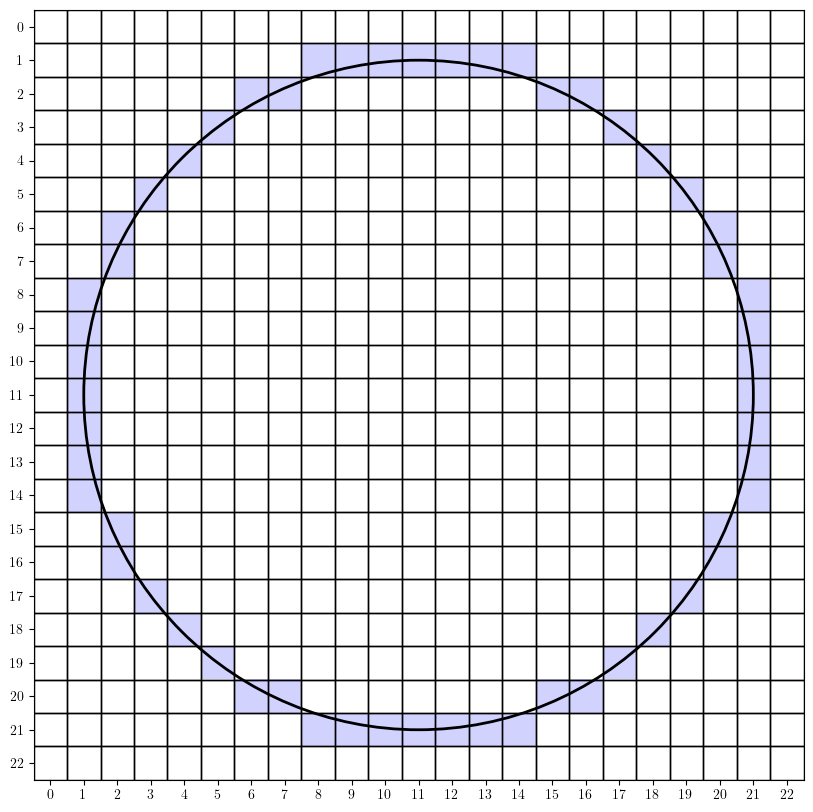

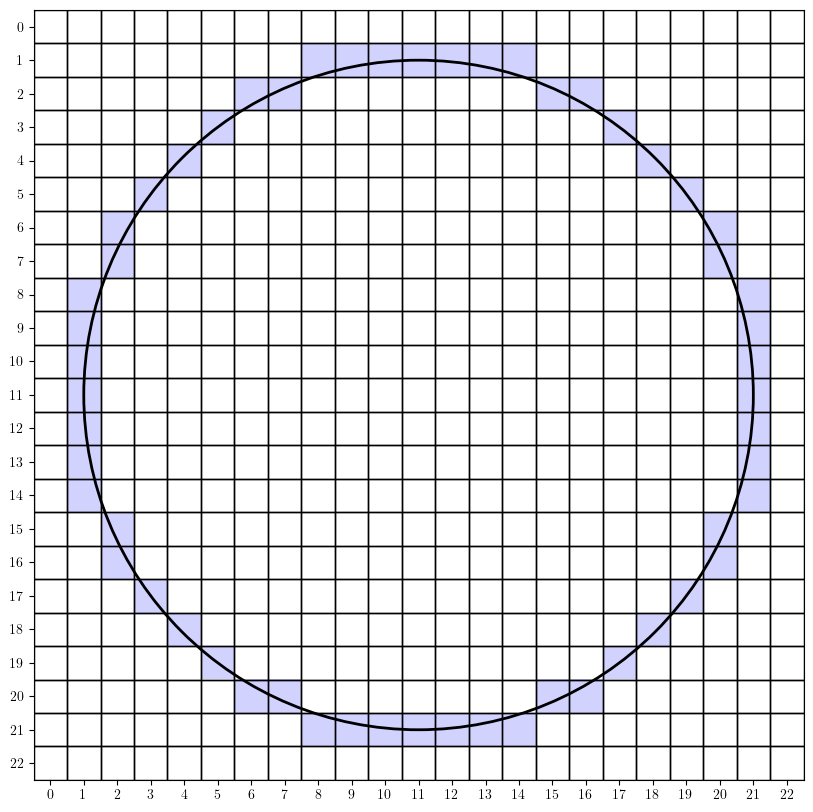

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from myst_nb import glue
plt.rcParams['text.usetex'] = True

def drawcircle(R, cx, cy, radius, colour):
    D, x, y = 5 - 4 * radius, radius, 0
    while y <= x:
        for i in range(3):
            R[cx + x, cy + y, i] = colour[i]
            R[cx + x, cy - y, i] = colour[i]
            R[cx - x, cy + y, i] = colour[i]
            R[cx - x, cy - y, i] = colour[i] 
            R[cx + y, cy + x, i] = colour[i]
            R[cx + y, cy - x, i] = colour[i]
            R[cx - y, cy + x, i] = colour[i]
            R[cx - y, cy - x, i] = colour[i]
        
        if D > 0:
            D -= 8 * x - 8
            x -= 1
        
        D += 8 * y + 12
        y += 1
        
    return R

        
def rasterisecircle(Nx, Ny, cx, cy, r, colour):
    img = 255 * np.ones((Ny, Nx, 3)).astype(int)
    img = drawcircle(img, cx, cy, r, colour)
    fig, ax = plt.subplots(figsize=(10, 10))
    imgplot = plt.imshow(img)
    ax.add_patch(plt.Circle((cx, cy), r, fill=False, lw=2))
    for i in range(Nx):
        for j in range(Ny):
            ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))
    
    plt.xticks(range(Nx))
    plt.yticks(range(Ny))
    return fig


Nx, Ny = 23, 23
cx, cy, r = 11, 11, 10
blue = [210, 210, 255]
green = [230, 255, 230]
white = [255, 255, 255]
fig = rasterisecircle(Nx, Ny, cx, cy, r, blue)

glue("midpoint-raster-plot", fig, display=False)